In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numba import njit

# Keplar Orbit around the Earth
We can determine the trajectory of a body in a keplar orbit around the Earth by solving the following equation of motion:

$$\frac{d^2\vec{r}}{dt^2}=-\frac{GM}{r^3}\vec{r}$$

Where $\vec{r}$ is the position vector in 2D (since the motion of a 2-body system is restricted to a plane), $M$ is the mass of the Earth and $G$ is the universal gravitational constant. This second-order ODE can be simplified into 2 first-order ODEs: 

$$\frac{d\vec{r}}{dt}=\vec{v}$$
$$\frac{d\vec{v}}{dt}=-\frac{GM}{r^3}\vec{r}$$

These are linear first order ODEs which can be integrated using any numerical method. However, before we integrate, we should first determine some conserved quanities from the initial conditions, such as the specific orbital energy $E$, specific angular momentum $h$, and the time period $T$. The specific orbital energy is given by the sum of the kinetic and potential energy: 

$$E=E_{k}+E_{p}=\frac{v^2}{2}-\frac{\mu}{r}$$

Where $v$ is the speed of the orbiting body, $r$ is the magnitude of the position vector, and $\mu=GM$ is called the gravitational parameter. For an eliptical orbit, the specific angular momentum is $h=\sqrt{\mu a(1-e^2)}$ where $a$ is the semi-major axis of the orbit and $e$ is the eccentricity. Since $v_p=h/r_p$ at the perigee, we can substitute in the above equation to recover: 

$$E=-\frac{\mu}{2a}$$

This relation between the energy and semi-major axis of the orbit is useful for determining the time period of the orbit: 

$$T=2\pi\sqrt{\frac{a^3}{\mu}}$$

In [2]:
# Physical constants
R_e = 6378e3                    # Radius of Earth (m)
M_e = 5.972e24                  # Mass of Earth (kg)
G = 6.6743e-11                  # Gravitational constant (m^3/kg/s^2)
mu = (G*M_e)                    # Gravitational parameter (m^3/s^2)

# Initial conditions
alt_p = 300e3                   # Perigee altitute (m)
r_p = R_e + alt_p               # Initial position at perigee (m)
v_p = 9.5e3                     # Initial speed at perigee (m/s)

# Orbit properties
E_i = (v_p**2/2) - (mu/r_p)     # Specific orbital energy (J/kg)
h_i = v_p*r_p                   # Specific angular momentum (m^2/s/kg)
a = -mu/(2*E_i)                 # Semi-major axis (m)
r_a = 2*a - r_p                 # Position at apogee (m)
alt_a = r_a - R_e               # Apogee altitude (m)
T = 2*np.pi*np.sqrt(a**3/mu)    # Orbital period (s)

print(f'Specific Energy (J/kg) = {E_i:.4e}')
print(f'Specific Angular Momentum (m^2/s/kg) = {h_i:.4e}')
print(f'Apogee Altitude (km) = {alt_a/1e3:.4e}')
print(f'Orbital Period (hrs) = {T/3600:.4f}')

Specific Energy (J/kg) = -1.4562e+07
Specific Angular Momentum (m^2/s/kg) = 6.3441e+10
Apogee Altitude (km) = 1.4316e+04
Orbital Period (hrs) = 4.4262


Due to the conservation of angular momentum and energy, these quantities should theoretically remain constant throughout the simulation. Similarly, the time period and geometric paramters of a stable elliptic orbit (perigee, apogee, semi-major axis, etc) should remain fixed. Hence, any fluctuations observed in these quantities must be a feature of numerical errors. We will monitor these for different methods of integration.

## RK4 Integration
We can solve the coupled first-order ODEs using the RK4 method of integration which is accurate upto the 4th-order, making it less sensitive to truncation error. For a differential equation of the form $dy/dt=f(y)$, the update procedure is as follows: 

$$y_{n+1} = y_n + \frac{(k_1 + 2k_2 + 2k_3 + k_4)}{6}dt$$

Where,

$$k_1=f(y_n), \ k_2 = f\bigg(y_n + \frac{k_1}{2}dt\bigg), \ k_3 = f\bigg(y_n + \frac{k_2}{2}dt\bigg), \ k_4 = f\bigg(y_n + k_3dt\bigg)$$

In [3]:
# RK4 integrator
@njit
def acc(r):
    rnorm = np.sqrt(r[0]**2 + r[1]**2)
    return -mu*r/rnorm**3

@njit
def rk4_step(r, v, dt):

    # Derivative function
    def f(r, v):
        return v, acc(r)

    k1r, k1v = f(r, v)
    k2r, k2v = f(r + 0.5*dt*k1r, v + 0.5*dt*k1v)
    k3r, k3v = f(r + 0.5*dt*k2r, v + 0.5*dt*k2v)
    k4r, k4v = f(r + dt*k3r, v + dt*k3v)

    r_next = r + dt*(k1r + 2*k2r + 2*k3r + k4r)/6
    v_next = v + dt*(k1v + 2*k2v + 2*k3v + k4v)/6

    return r_next, v_next

@njit
def rk4_integrate(r0, v0, dt, N):
    # Storage arrays
    r1 = np.zeros((N, 2))
    v1 = np.zeros((N, 2))
    t1 = np.zeros(N)
    
    r, v = r0, v0
    r1[0], v1[0] = r, v
    
    # Integrate
    for i in range(1, N):
        r, v = rk4_step(r, v, dt)
        r1[i], v1[i] = r, v
        t1[i] = t1[i-1] + dt

    return r1, v1, t1

In [4]:
%%time
# Simulation parameters
r0 = np.array([r_p, 0.0])
v0 = np.array([0.0, v_p])
dt = 45
n_orbits = 10000
N = int(np.round(n_orbits*T/dt))

r1, v1, t1 = rk4_integrate(r0, v0, dt, N)

CPU times: total: 20.7 s
Wall time: 21.7 s


## Stoermer's Rule Integration
Stoermer's method of integration is a second-order numerical method for equations of the form $d^2y/dt^2=f(y)$, with initial conditions $y(t_0)=y_0$ and $y'(t_0)=v_0$. This method only updates the position vector, and then reconstructs the velocity from neighbouring positions. From the Taylor expansion, we determine the first step: 

$$y_1 = y_0 + v_0dt + \frac{1}{2}f(y_0)dt^2$$

This gives us the first two steps, which can be used to construct the remaining positions from the update function: 

$$y_{i+1} = 2y_i - y_{i-1} + f(y_i)dt^2$$

Finally, the velocities are determined from the following relation:

$$v_{i} = \frac{(y_i - y_{i-1})}{dt} + \frac{1}{2}f(y_i)dt$$

In [5]:
# Stoermer integrator
@njit
def stoermer_integrate(r0, v0, dt, N):
    r2 = np.zeros((N+1, 2))
    v2 = np.zeros((N+1, 2))
    t2 = np.zeros(N+1)

    # Initial conditions
    r2[0], v2[0] = r0, v0

    # First step
    r2[1] = r2[0] + v2[0]*dt + 0.5*acc(r2[0])*dt**2

    for i in range(1, N):
        r2[i+1] = 2*r2[i] - r2[i-1] + acc(r2[i])*dt**2
        v2[i] = (r2[i] - r2[i-1])/(dt) + 0.5*acc(r2[i])*dt
        t2[i+1] = t2[i] + dt

    v2[N] = (r2[N] - r2[N-1])/(dt) + 0.5*acc(r2[N])*dt

    return r2, v2, t2

In [6]:
%%time
# Simulation parameters
r0 = np.array([r_p, 0.0])
v0 = np.array([0.0, v_p])
dt = 45
n_orbits = 10000
N = int(np.round(n_orbits*T/dt))

r2, v2, t2 = stoermer_integrate(r0, v0, dt, N)

CPU times: total: 4.91 s
Wall time: 5.17 s


## Results
Observing the runtime of both simulations for the same step-size and number of orbits (i.e. the same number of steps), we can see that Stoermer's rule integration is significantly faster than RK4 (by a factor of 4, for the chosen paramters). Both methods give us the spatial coordinates and velocity at every time step, which we can use to determine the trajectory, orbital energy and angular momentum.

### Orbital Trajectory

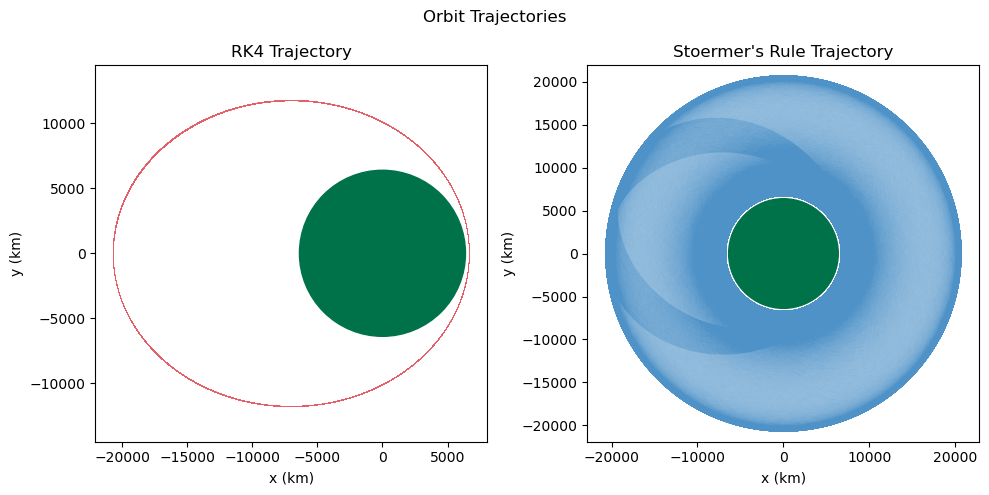

In [7]:
# Plot trajectory
r_x1, r_y1 = r1[:,0], r1[:,1]
r_x2, r_y2 = r2[:,0], r2[:,1]

fig, axs = plt.subplots(1, 2, figsize=(10, 5))

# RK4 trajectory
axs[0].plot(r_x1/1e3, r_y1/1e3, linewidth=0.01, alpha=0.7, c='#dc1a26')
circle1 = plt.Circle((0,0), R_e/1e3, color='#007249')
axs[0].add_patch(circle1)
axs[0].set_xlabel('x (km)')
axs[0].set_ylabel('y (km)')
axs[0].set_title('RK4 Trajectory')
axs[0].axis('equal')

# Stoermer trajectory
axs[1].plot(r_x2/1e3, r_y2/1e3, linewidth=0.01, alpha=0.7, c='#0464b0')
circle2 = plt.Circle((0,0), R_e/1e3, color='#007249')
axs[1].add_patch(circle2)
axs[1].set_xlabel('x (km)')
axs[1].set_ylabel('y (km)')
axs[1].set_title("Stoermer's Rule Trajectory")
axs[1].axis('equal')

plt.suptitle('Orbit Trajectories')
plt.tight_layout()
plt.show()

Clearly, the RK4 method is superior for determining the trajectory of the spacecraft for a long time (10,000 orbits). The Stoermer method trajectory displays significant precession over time, leading to an orbit that eventually precesses around the entire earth (shown in green).

### Apogee and Orbital Period
The apogee and perigee of the numerically determined orbit can be found from the maxima and minima of the radius $|\vec{r}|=\sqrt{r_x^2+r_y^2}$ for a single orbit. The semi-major axis is by definition half of the sum of these two distances. This can in turn be used to find the numerical orbital period from the relation: 

$$T=2\pi\sqrt{\frac{a^3}{\mu}}$$

In [8]:
# Apogee, perigee and orbital period
@njit
def apogee_perigee(r, t, T, dt, R_e):

    n = int(np.round(T/dt)) # number of steps in one orbit
    
    r_orb = r[:n+1]
    t_orb = t[:n+1]
    R_orb = np.sqrt(r_orb[:,0]**2 + r_orb[:,1]**2)

    idx_a = np.argmax(R_orb)
    idx_p = np.argmin(R_orb)

    R_a = R_orb[idx_a]
    R_p = R_orb[idx_p]

    Alt_a = R_a - R_e
    Alt_p = R_p - R_e

    return R_a, R_p, Alt_a

@njit
def orbital_period(R_a, R_p):
    A = 0.5*(R_a + R_p)
    T_orb = 2*np.pi*np.sqrt(A**3/mu)
    return A, T_orb

In [9]:
R_a1, R_p1, Alt_a1 = apogee_perigee(r1, t1, T, dt, R_e)
R_a2, R_p2, Alt_a2 = apogee_perigee(r2, t2, T, dt, R_e)

A1, T1_orb = orbital_period(R_a1, R_p1)
A2, T2_orb = orbital_period(R_a2, R_p2)

print(f"RK4 Apogee Altitude (km) = {Alt_a1/1e3:.4e}")
print(f"Stoermer Apogee Altitude (km) = {Alt_a2/1e3:.4e} \n")

print(f"RK4 Orbital Period (hrs) = {T1_orb/3600:.4f}")
print(f"Stoermer Orbital Period (hrs) = {T2_orb/3600:.4f}")

RK4 Apogee Altitude (km) = 1.4316e+04
Stoermer Apogee Altitude (km) = 1.4345e+04 

RK4 Orbital Period (hrs) = 4.4262
Stoermer Orbital Period (hrs) = 4.4331


In [10]:
# Percentage Error
def err(x, x0):
    return abs((x-x0)/x0)*100

r_a = 2*a-r_p-R_e # Exact apogee

print(f"RK4 Apogee % Error = {err(Alt_a1, r_a):.2e}")
print(f"Stoermer Apogee % Error = {err(Alt_a2, r_a):.2e} \n")

print(f"RK4 Orbital Period % Error = {err(T1_orb, T):.2e}")
print(f"Stoermer Orbital Period % Error = {err(T2_orb, T):.2e}")

RK4 Apogee % Error = 4.36e-05
Stoermer Apogee % Error = 2.00e-01 

RK4 Orbital Period % Error = 3.42e-05
Stoermer Orbital Period % Error = 1.57e-01


The percentage error of both the apogee and time period is nearly 4 orders of magnitude lower for the RK4 method compared to Stoermer's method. Hence, if we were interested in these values for our simulation, it is better to use RK4. 

### Specific Energy and Angular Momentum
The specific energy at each time-step is calculated using the previously mentioned equation: 

$$E=E_{k}+E_{p}=\frac{v^2}{2}-\frac{\mu}{r}$$

Where we use $v=|\vec{v}|$ and $r=|\vec{r}|$ from the numerical solutions. The specific angular momentum is normally given by $\vec{h}=\vec{r}\times\vec{v}$, but since we know $\vec{v}$ and $\vec{r}$ lie in the xy-plane, only the z-component of the angular momentum must survive. Hence, we can use the following formula to determine the magnitude of the angular momentum: 

$$|\vec{h}|=r_xv_y-r_yv_x$$

To compare the two integration methods, we are interested in the propogation of numerical errors in these quantities, since we know from conservation laws that energy and angular momentum must remain constant. Here, I have used the relative error with respect to the initial values to track their change over time: 

$$\text{Relative Error in x (\%)} = \bigg|\frac{x_i-x_0}{x_0}\bigg|\times100 = \bigg|\frac{\Delta x}{x_0}\bigg|\times100$$

In [11]:
# Specific energy 
@njit
def energy(r, v):
    V = np.sqrt(v[:,0]**2 + v[:,1]**2)
    R = np.sqrt(r[:,0]**2 + r[:,1]**2)
    E = 0.5*V**2 - mu/R
    return E

# Specific angular momentum
@njit
def angular_momentum(r, v):
    h = r[:,0]*v[:,1] - r[:,1]*v[:,0]
    return h

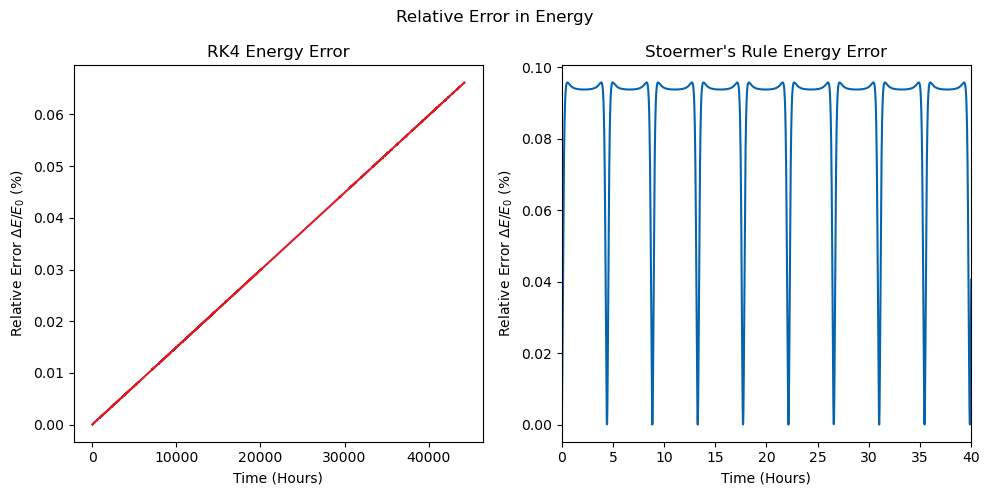

In [12]:
# Energy plots
E1 = energy(r1, v1)
E2 = energy(r2, v2)

fig, axs = plt.subplots(1, 2, figsize=(10, 5))

# RK4 energy
axs[0].plot(t1/3600, abs((E1-E1[0])/E1[0])*100, c='#dc1a26')
axs[0].set_xlabel('Time (Hours)')
axs[0].set_ylabel(r'Relative Error $\Delta E/E_0$ (%)')
axs[0].set_title('RK4 Energy Error')

# Stoermer energy
axs[1].plot(t2/3600, abs((E2-E2[0])/E2[0])*100, c='#0464b0')
axs[1].set_xlabel('Time (Hours)')
axs[1].set_ylabel(r'Relative Error $\Delta E/E_0$ (%)')
axs[1].set_title("Stoermer's Rule Energy Error")
axs[1].set_xlim(0, 40)

plt.suptitle('Relative Error in Energy')
plt.tight_layout()
plt.show()

The error in the RK4 method increases continuously as a function of time, whereas Stoermer's method gives us an oscillating error which remains below a certain threshold irrespective of the number of orbital periods. Note that the plot only shows the relative error upto 40 hours in order to display the oscillations, but these oscillations continue to stay below 0.1% upto 40,000+ hours. The frequency and amplitude of these oscillations depend on the step-size, as does the slope of the error in the RK4 method.

Hence, if we were interested in maintaining the conservation of energy instead of the trajectory for our simulation, Stoermer's method is preferrable over RK4, since the energy error does not grow with time and can be contained within a finite range. 

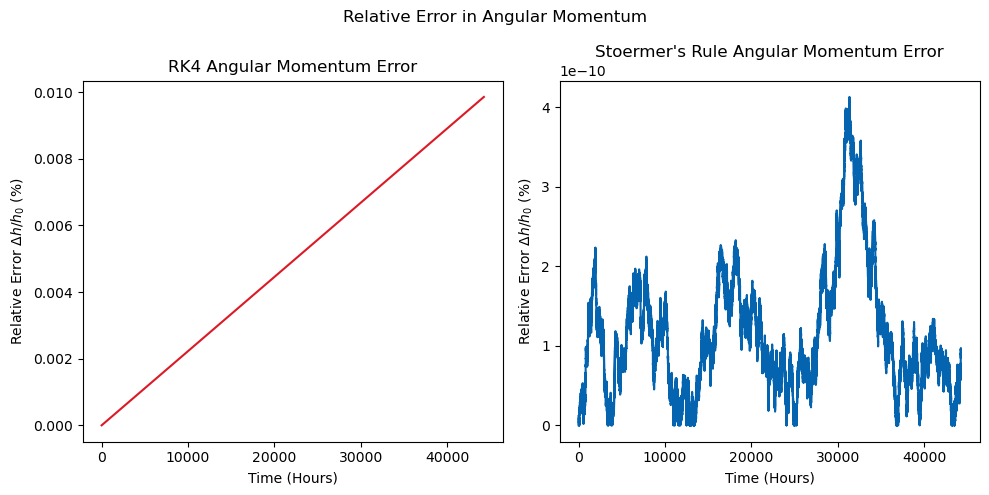

In [13]:
# Angular momentum plots
h1 = angular_momentum(r1, v1)
h2 = angular_momentum(r2, v2)

fig, axs = plt.subplots(1, 2, figsize=(10, 5))

# RK4 angular momentum
axs[0].plot(t1/3600, abs((h1-h1[0])/h1[0])*100, c='#dc1a26')
axs[0].set_xlabel('Time (Hours)')
axs[0].set_ylabel(r'Relative Error $\Delta h/h_0$ (%)')
axs[0].set_title('RK4 Angular Momentum Error')

# Stoermer angular momentum
axs[1].plot(t2/3600, abs((h2-h2[0])/h2[0])*100, c='#0464b0')
axs[1].set_xlabel('Time (Hours)')
axs[1].set_ylabel(r'Relative Error $\Delta h/h_0$ (%)')
axs[1].set_title("Stoermer's Rule Angular Momentum Error")

plt.suptitle('Relative Error in Angular Momentum')
plt.tight_layout()
plt.show()

The angular momentum error in the RK4 method also shows a continuous increase with respect to time, just like the energy error but with a slightly lower slope. On the other hand, Stoermer's method angular momentum error shows no correlation with time and instead appears to fluctuate randomly, possibly due to roundoff errors. However, these fluctuations are $~8$ orders of magnitude smaller than the RK4 error, and can therefore be considered negligible in comparison. 

Just like the energy, angular momentum conservation is preserved very well by Stoermer's rule integration and is therefore preferable for long-time simulations where angular momentum is the quantity of interest. In conclusion, it appears that the method of integration chosen for a problem must be motivated by the quantities of interest prior to the computational experiment, since different methods minimize different kinds of errors. 